In [69]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/class_dict.csv
/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/metadata.csv
/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/valid/8285_sat.jpg
/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/valid/127801_sat.jpg
/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/valid/198275_sat.jpg
/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/valid/393509_sat.jpg
/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/valid/262504_sat.jpg
/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/valid/651633_sat.jpg
/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/valid/392604_sat.jpg
/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/valid/411176_sat.jpg
/kaggle/input/datasets/balraj98/deepglobe-land

In [70]:
import os
base = '/kaggle/input/deepglobe-land-cover-classification-dataset'
print(os.listdir(base))

train = os.path.join(base, 'train')
files = os.listdir(train)
print(len(files))
print(files[:6])

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/deepglobe-land-cover-classification-dataset'

In [ ]:
import os
for d in os.listdir('/kaggle/input'):
    print(d)

In [ ]:
for root, dirs, files in os.walk('/kaggle/input'):
    print(root, len(files))

In [ ]:
import os
base = '/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset'
print(os.listdir(base))

train = os.path.join(base, 'train')
files = sorted(os.listdir(train))
print(len(files))
print(files[:6])

In [ ]:
import pandas as pd
print(pd.read_csv(base + '/class_dict.csv'))

(2448, 2448) (2448, 2448)


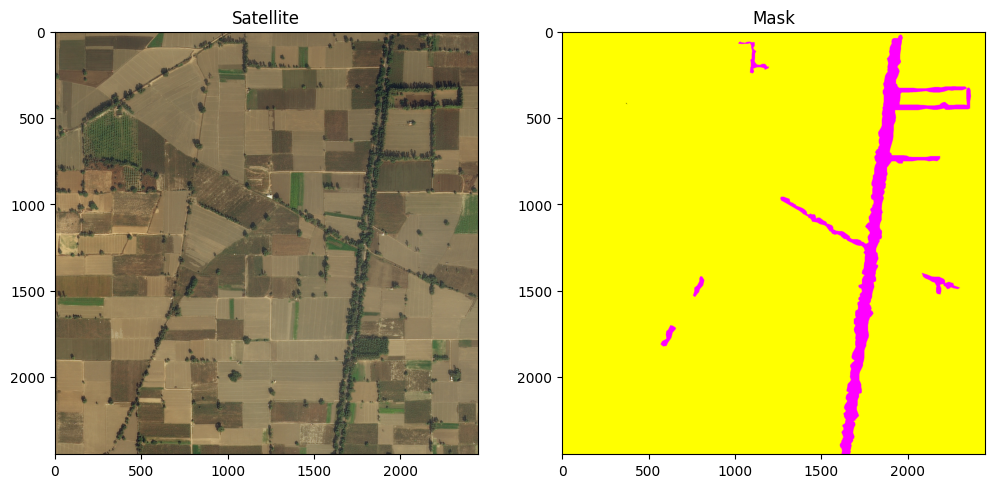

In [71]:
import matplotlib.pyplot as plt
from PIL import Image

name = '100694'
img  = Image.open(f'{train}/{name}_sat.jpg')
mask = Image.open(f'{train}/{name}_mask.png')
print(img.size, mask.size)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(img);  plt.title('Satellite')
plt.subplot(1,2,2); plt.imshow(mask); plt.title('Mask')
plt.show()

In [72]:
import numpy as np

def mask_to_class(mask_img):
    m = np.array(mask_img.convert('RGB')) >= 128   # True/False per channel
    code = m[...,0]*4 + m[...,1]*2 + m[...,2]*1
    lut = {
        3: 0,  # urban      (0,255,255)
        6: 1,  # agriculture(255,255,0)
        5: 2,  # rangeland  (255,0,255)
        2: 3,  # forest     (0,255,0)
        1: 4,  # water      (0,0,255)
        7: 5,  # barren     (255,255,255)
        0: 6,  # unknown    (0,0,0)
    }
    out = np.zeros(code.shape, dtype=np.uint8)
    for k, v in lut.items():
        out[code == k] = v
    return out

cls = mask_to_class(mask)
print(cls.shape, np.unique(cls, return_counts=True))

(2448, 2448) (array([1, 2, 6], dtype=uint8), array([5747668,  245019,      17]))


In [73]:
import random
ids = sorted({f.split('_')[0] for f in os.listdir(train)})
print(len(ids))   # 803 varanum

random.seed(42)
random.shuffle(ids)
n = len(ids)
train_ids = ids[:int(0.8*n)]
val_ids   = ids[int(0.8*n):int(0.9*n)]
test_ids  = ids[int(0.9*n):]
print(len(train_ids), len(val_ids), len(test_ids))

803
642 80 81


In [75]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A

MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)
TILE = 512

class DeepGlobeDataset(Dataset):
    def __init__(self, ids, root, train=True, samples_per_image=4):
        self.ids = ids
        self.root = root
        self.train = train
        self.spi = samples_per_image if train else 1

        if train:
            self.aug = A.Compose([
                A.RandomCrop(TILE, TILE),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                A.Normalize(mean=MEAN, std=STD),
            ])
        else:
            self.aug = A.Compose([
                A.CenterCrop(TILE, TILE),
                A.Normalize(mean=MEAN, std=STD),
            ])

    def __len__(self):
        return len(self.ids) * self.spi

    def __getitem__(self, idx):
        i = self.ids[idx // self.spi]
        img  = np.array(Image.open(f'{self.root}/{i}_sat.jpg').convert('RGB'))
        mask = mask_to_class(Image.open(f'{self.root}/{i}_mask.png'))
        out = self.aug(image=img, mask=mask)
        x = torch.from_numpy(out['image']).permute(2,0,1).float()
        y = torch.from_numpy(out['mask']).long()
        return x, y

In [ ]:
!pip install -q albumentations segmentation-models-pytorch

In [ ]:
train_ds = DeepGlobeDataset(train_ids, train, train=True)
val_ds   = DeepGlobeDataset(val_ids,   train, train=False)

train_dl = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

x, y = next(iter(train_dl))
print(x.shape, y.shape, y.unique())

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A

MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)
TILE = 512

class DeepGlobeDataset(Dataset):
    def __init__(self, ids, root, train=True, samples_per_image=4):
        self.ids = ids
        self.root = root
        self.train = train
        self.spi = samples_per_image if train else 1

        if train:
            self.aug = A.Compose([
                A.RandomCrop(TILE, TILE),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                A.Normalize(mean=MEAN, std=STD),
            ])
        else:
            self.aug = A.Compose([
                A.CenterCrop(TILE, TILE),
                A.Normalize(mean=MEAN, std=STD),
            ])

    def __len__(self):
        return len(self.ids) * self.spi

    def __getitem__(self, idx):
        i = self.ids[idx // self.spi]
        img  = np.array(Image.open(f'{self.root}/{i}_sat.jpg').convert('RGB'))
        mask = mask_to_class(Image.open(f'{self.root}/{i}_mask.png'))
        out = self.aug(image=img, mask=mask)
        x = torch.from_numpy(out['image']).permute(2,0,1).float()
        y = torch.from_numpy(out['mask']).long()
        return x, y

In [76]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A

MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)
TILE = 512

class DeepGlobeDataset(Dataset):
    def __init__(self, ids, root, train=True, samples_per_image=4):
        self.ids = ids
        self.root = root
        self.train = train
        self.spi = samples_per_image if train else 1

        if train:
            self.aug = A.Compose([
                A.RandomCrop(TILE, TILE),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                A.Normalize(mean=MEAN, std=STD),
            ])
        else:
            self.aug = A.Compose([
                A.CenterCrop(TILE, TILE),
                A.Normalize(mean=MEAN, std=STD),
            ])

    def __len__(self):
        return len(self.ids) * self.spi

    def __getitem__(self, idx):
        i = self.ids[idx // self.spi]
        img  = np.array(Image.open(f'{self.root}/{i}_sat.jpg').convert('RGB'))
        mask = mask_to_class(Image.open(f'{self.root}/{i}_mask.png'))
        out = self.aug(image=img, mask=mask)
        x = torch.from_numpy(out['image']).permute(2,0,1).float()
        y = torch.from_numpy(out['mask']).long()
        return x, y

In [ ]:
!pip install -q albumentations segmentation-models-pytorch

In [77]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import numpy as np
import random

class DeepGlobeDataset(Dataset):
    def __init__(self, ids, train_dir, size=(256, 256)):
        self.ids = ids
        self.train_dir = train_dir
        self.size = size

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        name = self.ids[idx]

        img_path = os.path.join(self.train_dir, f'{name}_sat.jpg')
        mask_path = os.path.join(self.train_dir, f'{name}_mask.png')

        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('RGB')

        # Resize
        image = image.resize(self.size, Image.BILINEAR)
        mask = mask.resize(self.size, Image.NEAREST)

        # Convert image
        image = np.array(image, dtype=np.float32) / 255.0
        image = torch.tensor(image).permute(2, 0, 1)

        # Convert RGB mask → class mask
        mask = mask_to_class(mask)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [88]:
train_dataset = DeepGlobeDataset(train_ids, train)
val_dataset   = DeepGlobeDataset(val_ids, train)
test_dataset  = DeepGlobeDataset(test_ids, train)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 642
Validation: 80
Test: 81


In [89]:
images, masks = next(iter(train_loader))

print("Image shape:", images.shape)
print("Mask shape:", masks.shape)
print("Mask classes:", torch.unique(masks))

Image shape: torch.Size([8, 3, 256, 256])
Mask shape: torch.Size([8, 256, 256])
Mask classes: tensor([0, 1, 2, 3, 4, 5, 6])


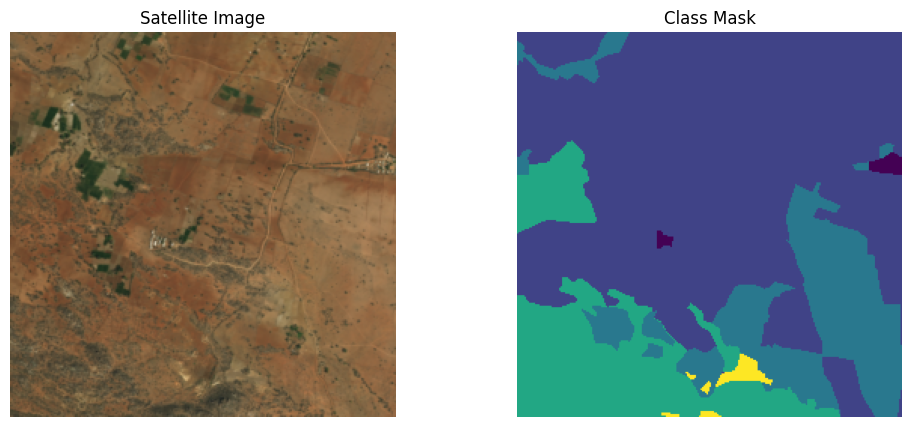

In [90]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(images[0].permute(1, 2, 0))
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masks[0])
plt.title("Class Mask")
plt.axis("off")

plt.show()

In [92]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [93]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(num_classes=7).to(device)

print("Device:", device)
print("U-Net model created successfully!")

Device: cuda
U-Net model created successfully!


In [94]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss and optimizer ready!")

Loss and optimizer ready!


In [96]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [98]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            running_loss += loss.item()

    return running_loss / len(loader)

print("Validation function ready!")

Validation function ready!


In [99]:
epochs = 5

for epoch in range(epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/5] Train Loss: 1.0438 Val Loss: 2.6019
Epoch [2/5] Train Loss: 0.9749 Val Loss: 1.0760
Epoch [3/5] Train Loss: 0.9288 Val Loss: 1.1257
Epoch [4/5] Train Loss: 0.9340 Val Loss: 1.1015
Epoch [5/5] Train Loss: 0.8765 Val Loss: 0.7932


In [101]:
torch.save(model.state_dict(), "deepglobe_unet.pth")

print("Model saved successfully!")

Model saved successfully!


In [102]:
model.eval()

image, true_mask = test_dataset[0]

with torch.no_grad():
    input_image = image.unsqueeze(0).to(device)
    output = model(input_image)

pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

print("Prediction shape:", pred_mask.shape)
print("Predicted classes:", np.unique(pred_mask))

Prediction shape: (256, 256)
Predicted classes: [0 1 4 5]


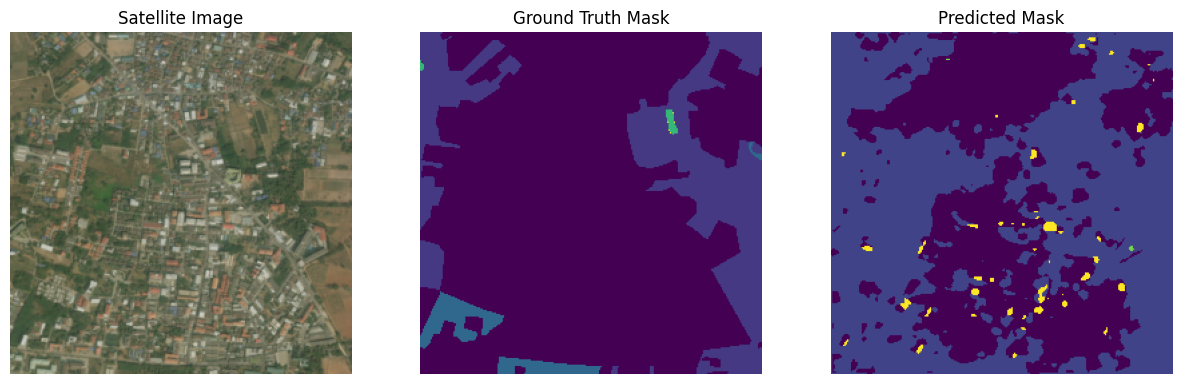

In [103]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(true_mask)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask)
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

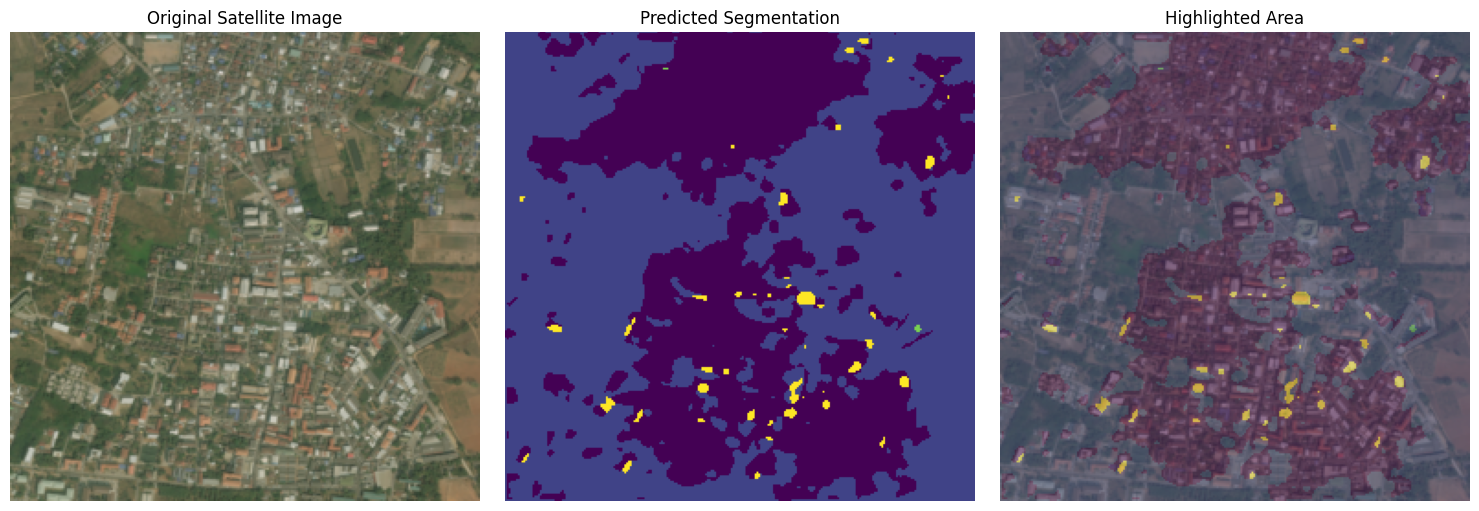

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Original image
original = image.permute(1, 2, 0).numpy()

# Prediction mask
prediction = pred_mask

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original Satellite Image")
plt.axis("off")

# Predicted segmentation
plt.subplot(1, 3, 2)
plt.imshow(prediction)
plt.title("Predicted Segmentation")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(original)
plt.imshow(prediction, alpha=0.45)
plt.title("Highlighted Area")
plt.axis("off")

plt.tight_layout()
plt.show()

In [105]:
segment(image, question) → mask

SyntaxError: invalid character '→' (U+2192) (741448145.py, line 1)

In [108]:
def segment(image, question):

    model.eval()

    # Image is already a tensor from DeepGlobeDataset
    if isinstance(image, torch.Tensor):
        img = image.clone()

        # If image is [3, H, W]
        if img.dim() == 3:
            img = img.unsqueeze(0)

        img = img.to(device)

    else:
        # For PIL / numpy input
        if isinstance(image, Image.Image):
            img = np.array(image)
        else:
            img = np.array(image)

        img = img.astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1).unsqueeze(0)
        img = img.to(device)

    # Model prediction
    with torch.no_grad():
        output = model(img)

    # Select class with highest probability
    mask = torch.argmax(output, dim=1)

    return mask.squeeze(0).cpu().numpy()

In [109]:
result_mask = segment(
    image,
    "What is in this area?"
)

print("Mask shape:", result_mask.shape)
print("Classes:", np.unique(result_mask))

Mask shape: (256, 256)
Classes: [0 1 4 5]


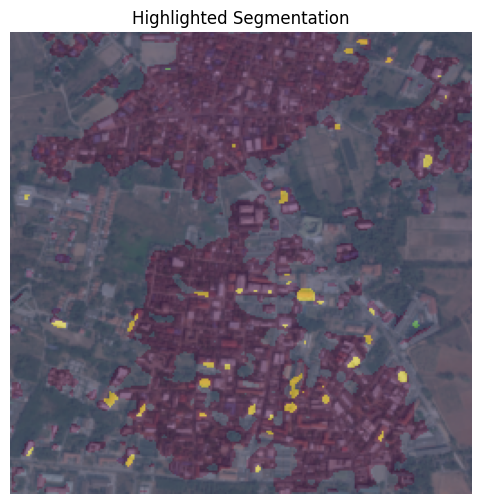

In [110]:
plt.figure(figsize=(6, 6))

plt.imshow(image.permute(1, 2, 0))
plt.imshow(result_mask, alpha=0.45)

plt.title("Highlighted Segmentation")
plt.axis("off")

plt.show()

In [111]:
CLASS_NAMES = {
    0: "urban",
    1: "agriculture",
    2: "rangeland",
    3: "forest",
    4: "water",
    5: "barren",
    6: "unknown"
}

def get_requested_class(question):
    question = question.lower()

    if "water" in question or "river" in question or "lake" in question:
        return 4

    elif "forest" in question or "tree" in question or "vegetation" in question:
        return 3

    elif "urban" in question or "city" in question or "built" in question:
        return 0

    elif "agriculture" in question or "farm" in question or "crop" in question:
        return 1

    elif "rangeland" in question:
        return 2

    elif "barren" in question or "land" in question:
        return 5

    else:
        return None

In [112]:
def segment(image, question):

    model.eval()

    # Convert image to tensor
    if isinstance(image, torch.Tensor):

        img = image.clone()

        if img.dim() == 3:
            img = img.unsqueeze(0)

        img = img.to(device)

    else:

        if isinstance(image, Image.Image):
            img = np.array(image)
        else:
            img = np.array(image)

        img = img.astype(np.float32) / 255.0

        img = torch.tensor(img).permute(2, 0, 1)
        img = img.unsqueeze(0).to(device)

    # Model prediction
    with torch.no_grad():
        output = model(img)

    predicted_mask = torch.argmax(output, dim=1)
    predicted_mask = predicted_mask.squeeze(0).cpu().numpy()

    # Find requested class
    requested_class = get_requested_class(question)

    # If user asks for a specific class
    if requested_class is not None:

        highlight_mask = (
            predicted_mask == requested_class
        ).astype(np.uint8)

        return highlight_mask

    # Otherwise return complete segmentation
    return predicted_mask

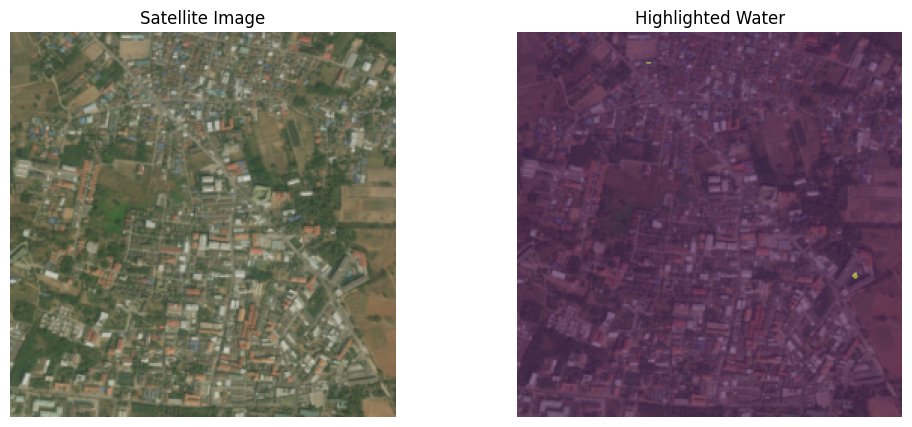

In [113]:
result = segment(
    image,
    "Highlight the water area"
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image.permute(1, 2, 0))
plt.imshow(result, alpha=0.5)
plt.title("Highlighted Water")
plt.axis("off")

plt.show()


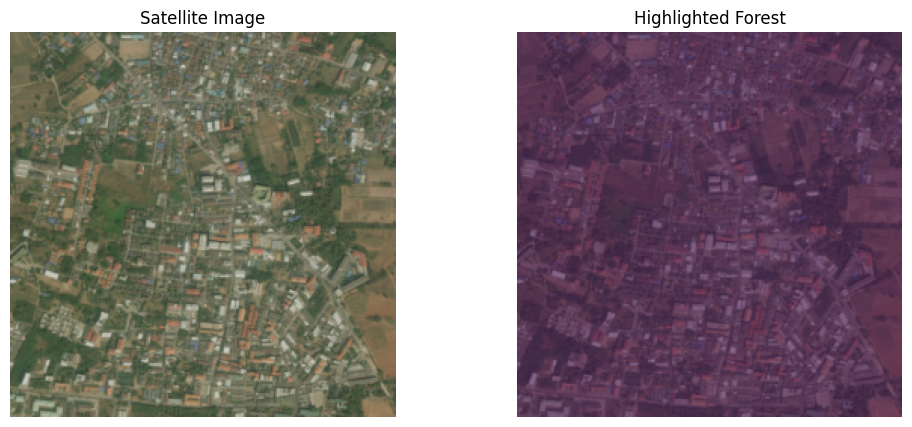

In [114]:
result = segment(
    image,
    "Highlight the forest area"
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image.permute(1, 2, 0))
plt.imshow(result, alpha=0.5)
plt.title("Highlighted Forest")
plt.axis("off")

plt.show()

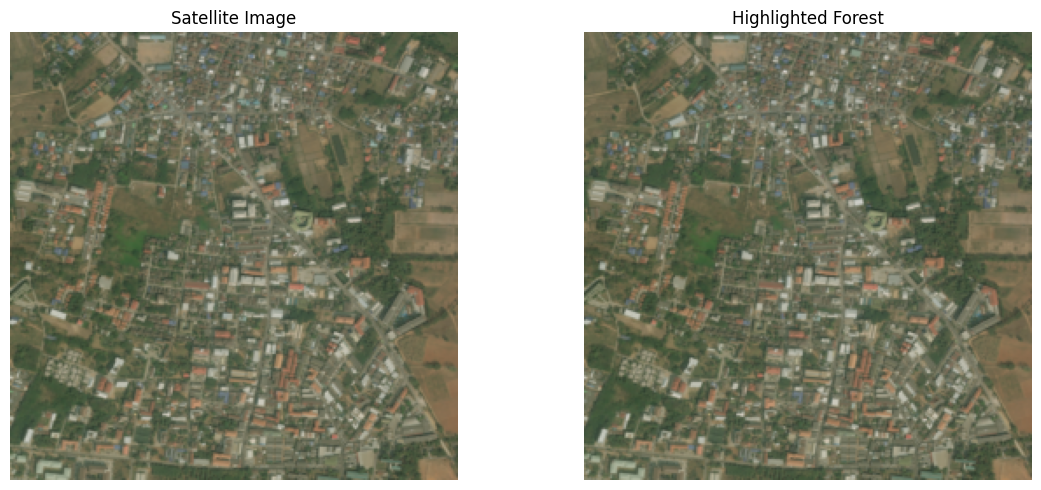

In [115]:
import numpy as np
import matplotlib.pyplot as plt

# Get forest mask
forest_mask = (result == 1).astype(np.uint8)   # change if your class mapping differs

# Original image
img = image.permute(1, 2, 0).cpu().numpy()

# Create overlay
overlay = img.copy()

# Highlight ONLY forest pixels
overlay[forest_mask == 1] = [0.0, 1.0, 0.0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(
    np.ma.masked_where(forest_mask == 0, forest_mask),
    alpha=0.6
)
plt.title("Highlighted Forest")
plt.axis("off")

plt.tight_layout()
plt.show()

In [117]:
forest_mask = (result == 1)

In [119]:
result = segment(image, "Highlight the forest area")

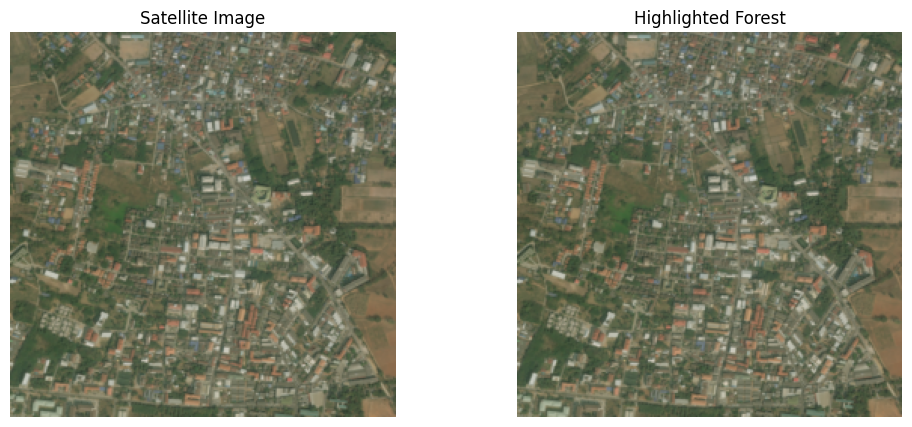

In [120]:
forest_mask = result.astype(bool)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image.permute(1, 2, 0))
plt.imshow(
    np.ma.masked_where(~forest_mask, forest_mask),
    alpha=0.7
)
plt.title("Highlighted Forest")
plt.axis("off")

plt.show()

In [121]:
print("Result shape:", result.shape)
print("Result unique values:", np.unique(result))
print("Forest pixels:", np.sum(result == 1))
print("Total pixels:", result.size)

Result shape: (256, 256)
Result unique values: [0]
Forest pixels: 0
Total pixels: 65536


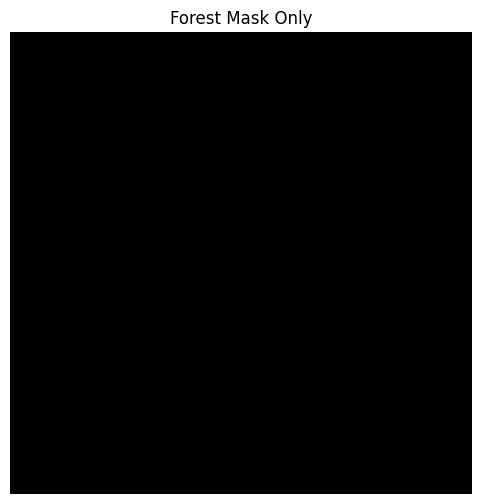

In [122]:
plt.figure(figsize=(6, 6))

plt.imshow(result, cmap="gray")
plt.title("Forest Mask Only")
plt.axis("off")

plt.show()

In [123]:
forest_pixels = np.sum(result == 1)
total_pixels = result.size

print("Forest pixels:", forest_pixels)
print("Forest percentage:", (forest_pixels / total_pixels) * 100)

Forest pixels: 0
Forest percentage: 0.0


In [124]:
full_mask = pred_mask

unique, counts = np.unique(full_mask, return_counts=True)

for cls, count in zip(unique, counts):
    print(
        CLASS_NAMES[int(cls)],
        ":", count,
        f"({count / full_mask.size * 100:.2f}%)"
    )

urban : 26902 (41.05%)
agriculture : 37984 (57.96%)
water : 14 (0.02%)
barren : 636 (0.97%)


In [125]:
print("Ground truth classes:", np.unique(true_mask))
print("Forest pixels in ground truth:", np.sum(true_mask.numpy() == 3))

Ground truth classes: [0 1 2 4 6]
Forest pixels in ground truth: 0


In [126]:
forest_test_ids = []

for name in test_ids:
    mask_path = os.path.join(train, f"{name}_mask.png")
    
    mask_img = Image.open(mask_path).convert("RGB")
    mask_class = mask_to_class(mask_img)

    if np.any(mask_class == 3):
        forest_test_ids.append(name)

print("Test images containing forest:", len(forest_test_ids))
print("First few:", forest_test_ids[:10])

Test images containing forest: 27
First few: ['518833', '952430', '978039', '182422', '428597', '147716', '170535', '749523', '713813', '619800']


In [127]:
forest_id = forest_test_ids[0]

forest_img = Image.open(
    os.path.join(train, f"{forest_id}_sat.jpg")
).convert("RGB")

forest_mask_gt = Image.open(
    os.path.join(train, f"{forest_id}_mask.png")
).convert("RGB")

forest_mask_gt = mask_to_class(forest_mask_gt)

print("Image:", forest_id)
print("Ground truth classes:", np.unique(forest_mask_gt))
print("Forest pixels:", np.sum(forest_mask_gt == 3))

Image: 518833
Ground truth classes: [0 1 2 3 4]
Forest pixels: 1891844


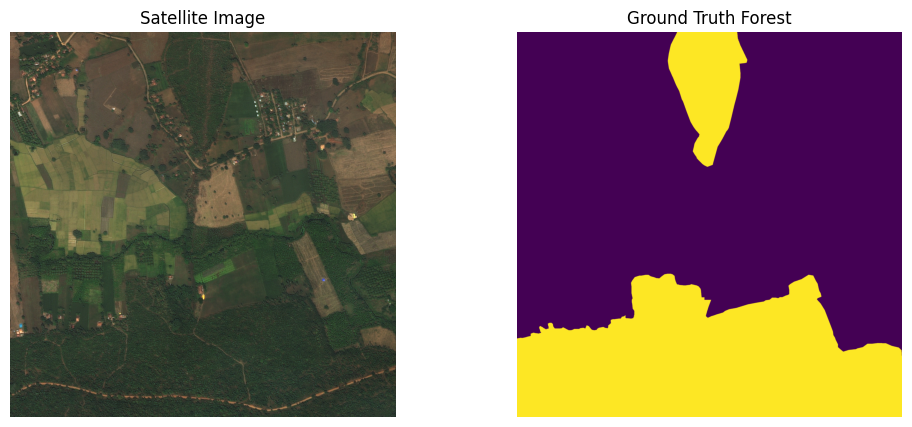

In [128]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(forest_img)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(forest_mask_gt == 3)
plt.title("Ground Truth Forest")
plt.axis("off")

plt.show()

In [129]:
# Prepare the selected forest image for the model

img_tensor = transform(forest_img).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(img_tensor)
    pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

print("Predicted classes:", np.unique(pred_mask))
print("Predicted forest pixels:", np.sum(pred_mask == 3))
print(
    "Predicted forest percentage:",
    np.sum(pred_mask == 3) / pred_mask.size * 100
)

NameError: name 'transform' is not defined

In [130]:
print("Has transform:", hasattr(test_dataset, "transform"))

if hasattr(test_dataset, "transform"):
    print("Transform found:", test_dataset.transform)

Has transform: False


In [131]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

img_tensor = transform(forest_img).unsqueeze(0).to(device)

print("Input shape:", img_tensor.shape)

Input shape: torch.Size([1, 3, 256, 256])


In [132]:
model.eval()

with torch.no_grad():
    output = model(img_tensor)
    pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

print("Predicted classes:", np.unique(pred_mask))
print("Predicted forest pixels:", np.sum(pred_mask == 3))
print(
    "Predicted forest percentage:",
    np.sum(pred_mask == 3) / pred_mask.size * 100
)

Predicted classes: [0 1 3 4 5]
Predicted forest pixels: 27949
Predicted forest percentage: 42.64678955078125


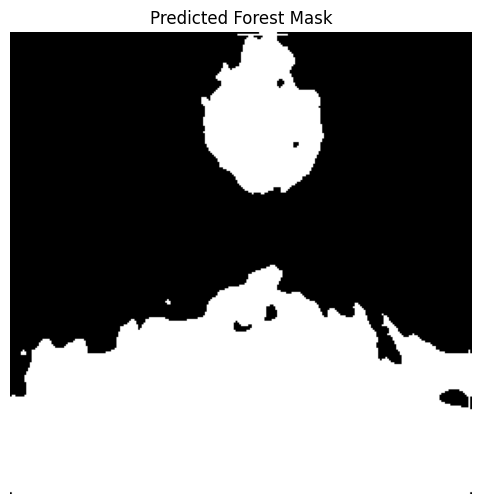

In [133]:
pred_forest = (pred_mask == 3)

plt.figure(figsize=(6, 6))
plt.imshow(pred_forest, cmap="gray")
plt.title("Predicted Forest Mask")
plt.axis("off")
plt.show()

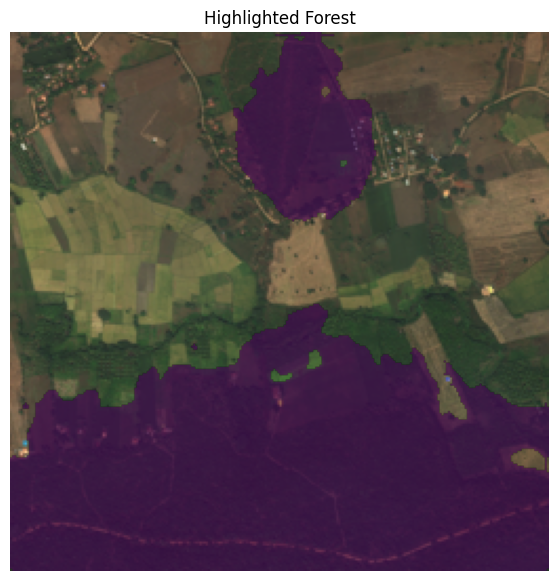

In [134]:
plt.figure(figsize=(7, 7))

plt.imshow(forest_img.resize((256, 256)))

plt.imshow(
    np.ma.masked_where(~pred_forest, pred_forest),
    alpha=0.6
)

plt.title("Highlighted Forest")
plt.axis("off")
plt.show()

In [137]:
def segment(image, question):
    """
    Segment the area requested by the user.
    Example:
    segment(image, "highlight the forest area")
    """

    question = question.lower()

    # For now, forest segmentation
    if "forest" in question or "tree" in question or "vegetation" in question:

        img = image.convert("RGB")

        img_tensor = transform(img).unsqueeze(0).to(device)

        model.eval()

        with torch.no_grad():
            output = model(img_tensor)
            pred = torch.argmax(output, dim=1)

        mask = pred.squeeze(0).cpu().numpy()

        # Forest = class 3
        forest_mask = (mask == 3).astype(np.uint8)

        return forest_mask

    else:
        return None

In [138]:
mask = segment(
    forest_img,
    "Highlight the forest area"
)

print("Mask shape:", mask.shape)
print("Mask values:", np.unique(mask))

Mask shape: (256, 256)
Mask values: [0 1]


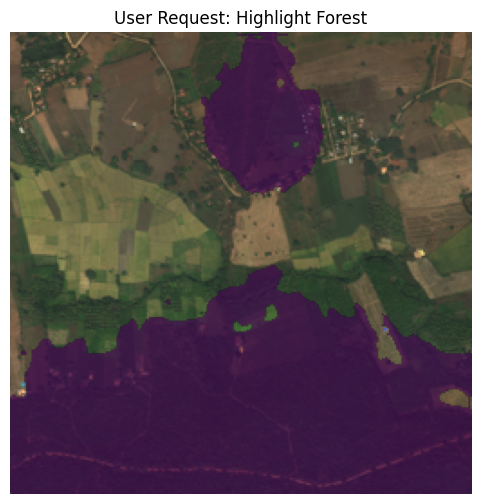

In [139]:
plt.figure(figsize=(6, 6))

plt.imshow(forest_img.resize((256, 256)))

plt.imshow(
    np.ma.masked_where(mask == 0, mask),
    alpha=0.6
)

plt.title("User Request: Highlight Forest")
plt.axis("off")
plt.show()

In [142]:
def segment(image, question):
    question = question.lower()

    # Map user words to DeepGlobe classes
    class_map = {
        "urban": 0,
        "city": 0,
        "building": 0,
        "buildings": 0,

        "agriculture": 1,
        "farm": 1,
        "farmland": 1,
        "crop": 1,

        "rangeland": 2,
        "grassland": 2,

        "forest": 3,
        "tree": 3,
        "trees": 3,
        "vegetation": 3,

        "water": 4,
        "river": 4,
        "lake": 4,

        "barren": 5,
        "bare land": 5,
        "bare": 5
    }

    target_class = None

    for word, cls in class_map.items():
        if word in question:
            target_class = cls
            break

    if target_class is None:
        return None

    # Convert image
    img = image.convert("RGB")

    # Prepare tensor
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():
        output = model(img_tensor)
        prediction = torch.argmax(output, dim=1)

    prediction = prediction.squeeze(0).cpu().numpy()

    # Requested class mask
    mask = (prediction == target_class).astype(np.uint8)

    return mask

In [143]:
mask = segment(
    forest_img,
    "Highlight the forest area"
)

print("Mask shape:", mask.shape)
print("Mask values:", np.unique(mask))

Mask shape: (256, 256)
Mask values: [0 1]


In [144]:
water_mask = segment(
    forest_img,
    "Highlight the water area"
)

print("Water mask:", np.unique(water_mask))

Water mask: [0 1]


In [145]:
def show_segmentation(image, question):

    mask = segment(image, question)

    if mask is None:
        print("Requested area is not supported.")
        return

    display_img = image.resize((256, 256))

    plt.figure(figsize=(7, 7))

    plt.imshow(display_img)

    plt.imshow(
        np.ma.masked_where(mask == 0, mask),
        alpha=0.6
    )

    plt.title("Highlighted Area")
    plt.axis("off")

    plt.show()

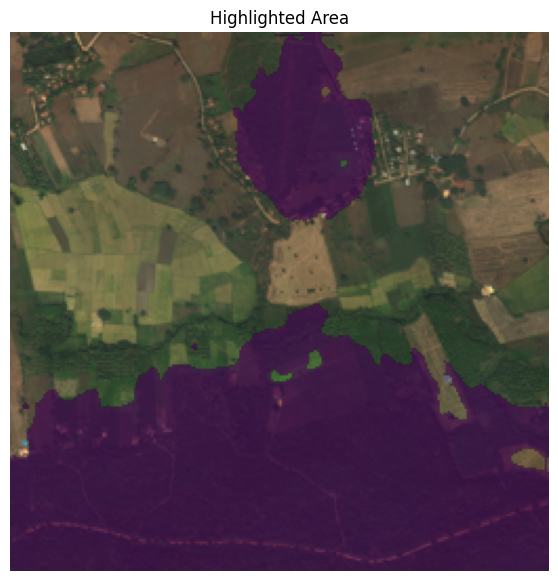

In [146]:
show_segmentation(
    forest_img,
    "Highlight the forest area"
)

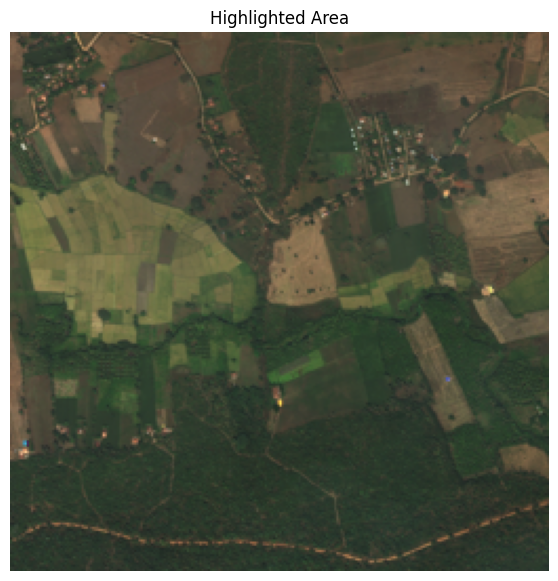

In [148]:
show_segmentation(
    forest_img,
    "Highlight the water area"
)

In [149]:
!pip install -q gradio

In [150]:
import gradio as gr

In [151]:
def gradio_segment(image, question):

    if image is None:
        return None, "Please upload an image."

    mask = segment(image, question)

    if mask is None:
        return image, "Supported: forest, water, agriculture, urban, rangeland, barren"

    display_img = image.resize((256, 256))

    plt.figure(figsize=(7, 7))
    plt.imshow(display_img)
    plt.imshow(
        np.ma.masked_where(mask == 0, mask),
        alpha=0.6
    )
    plt.axis("off")

    # Save visualization
    output_path = "/kaggle/working/highlighted_result.png"
    plt.savefig(output_path, bbox_inches="tight")
    plt.close()

    return output_path, "Area highlighted successfully!"

In [152]:
demo = gr.Interface(
    fn=gradio_segment,
    inputs=[
        gr.Image(type="pil", label="Satellite Image"),
        gr.Textbox(
            label="Question",
            placeholder="Highlight the forest area"
        )
    ],
    outputs=[
        gr.Image(label="Highlighted Area"),
        gr.Textbox(label="Status")
    ],
    title="Remote Sensing Area Highlighting",
    description="Upload a satellite image and ask which area to highlight."
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://2624bf701624e03f1d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [153]:
!pip install -q transformers

In [154]:
import torch
import numpy as np
from PIL import Image
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

seg_processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
)

seg_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
).to(device)

seg_model.eval()

print("General segmentation model loaded!")

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 15.0MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

General segmentation model loaded!


In [156]:
GENERAL_CLASSES = {
    "road": ["road", "roads", "street", "streets", "highway"],
    
    "building": ["building", "buildings", "house", "houses", "home", "homes"],
    
    "tree": ["tree", "trees"],
    
    "vegetation": ["vegetation", "plant", "plants", "grass"],
    
    "water": ["water", "river", "lake", "pond", "sea"],
    
    "car": ["car", "cars", "vehicle", "vehicles"],
    
    "person": ["person", "people", "human"],
    
    "sky": ["sky"],
    
    "forest": ["forest", "woods"],
    
    "field": ["field", "fields", "farm", "farmland", "agriculture", "crop"]
}

In [157]:
def find_general_class(question):
    question = question.lower()

    for category, keywords in GENERAL_CLASSES.items():
        for word in keywords:
            if word in question:
                return category

    return None

In [158]:
print("Number of classes:", len(seg_model.config.id2label))

for i, label in seg_model.config.id2label.items():
    print(i, ":", label)

Number of classes: 150
0 : wall
1 : building
2 : sky
3 : floor
4 : tree
5 : ceiling
6 : road
7 : bed 
8 : windowpane
9 : grass
10 : cabinet
11 : sidewalk
12 : person
13 : earth
14 : door
15 : table
16 : mountain
17 : plant
18 : curtain
19 : chair
20 : car
21 : water
22 : painting
23 : sofa
24 : shelf
25 : house
26 : sea
27 : mirror
28 : rug
29 : field
30 : armchair
31 : seat
32 : fence
33 : desk
34 : rock
35 : wardrobe
36 : lamp
37 : bathtub
38 : railing
39 : cushion
40 : base
41 : box
42 : column
43 : signboard
44 : chest of drawers
45 : counter
46 : sand
47 : sink
48 : skyscraper
49 : fireplace
50 : refrigerator
51 : grandstand
52 : path
53 : stairs
54 : runway
55 : case
56 : pool table
57 : pillow
58 : screen door
59 : stairway
60 : river
61 : bridge
62 : bookcase
63 : blind
64 : coffee table
65 : toilet
66 : flower
67 : book
68 : hill
69 : bench
70 : countertop
71 : stove
72 : palm
73 : kitchen island
74 : computer
75 : swivel chair
76 : boat
77 : bar
78 : arcade machine
79 : hovel

In [160]:
def general_segment(image, question):

    category = find_general_class(question)

    if category is None:
        return None, "I couldn't identify the requested area."

    image = image.convert("RGB")

    inputs = seg_processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = seg_model(**inputs)

    logits = outputs.logits

    # Resize prediction to original image size
    prediction = torch.nn.functional.interpolate(
        logits,
        size=image.size[::-1],
        mode="bilinear",
        align_corners=False
    )

    prediction = prediction.argmax(dim=1)[0].cpu().numpy()

    # Find matching ADE20K class
    target_ids = []

    for idx, label in seg_model.config.id2label.items():

        label_lower = label.lower()

        if category == "road" and "road" in label_lower:
            target_ids.append(idx)

        elif category == "building" and (
            "building" in label_lower or
            "house" in label_lower
        ):
            target_ids.append(idx)

        elif category == "tree" and "tree" in label_lower:
            target_ids.append(idx)

        elif category == "vegetation" and (
            "plant" in label_lower or
            "grass" in label_lower
        ):
            target_ids.append(idx)

        elif category == "water" and (
            "water" in label_lower or
            "sea" in label_lower
        ):
            target_ids.append(idx)

        elif category == "car" and (
            "car" in label_lower or
            "vehicle" in label_lower
        ):
            target_ids.append(idx)

        elif category == "person" and "person" in label_lower:
            target_ids.append(idx)

        elif category == "sky" and "sky" in label_lower:
            target_ids.append(idx)

        elif category == "forest" and (
            "tree" in label_lower or
            "forest" in label_lower
        ):
            target_ids.append(idx)

        elif category == "field" and (
            "field" in label_lower or
            "grass" in label_lower
        ):
            target_ids.append(idx)

    if len(target_ids) == 0:
        return None, f"No trained class found for '{category}'."

    mask = np.isin(prediction, target_ids).astype(np.uint8)

    return mask, f"Highlighted: {category}"

In [161]:
def gradio_segment(image, question):

    if image is None:
        return None, "Please upload an image."

    if question is None or question.strip() == "":
        return image, "Please enter a question."

    mask, status = general_segment(image, question)

    if mask is None:
        return image, status

    display_img = image.resize((mask.shape[1], mask.shape[0]))

    plt.figure(figsize=(8, 8))

    plt.imshow(display_img)

    highlighted = np.ma.masked_where(mask == 0, mask)

    plt.imshow(
        highlighted,
        alpha=0.55
    )

    plt.axis("off")
    plt.title(status)

    output_path = "/kaggle/working/highlighted_result.png"

    plt.savefig(
        output_path,
        bbox_inches="tight"
    )

    plt.close()

    return output_path, status

In [162]:
import gradio as gr

demo = gr.Interface(
    fn=gradio_segment,

    inputs=[
        gr.Image(
            type="pil",
            label="Satellite Image"
        ),

        gr.Textbox(
            label="Question",
            placeholder="Example: Highlight the roads"
        )
    ],

    outputs=[
        gr.Image(
            label="Highlighted Area"
        ),

        gr.Textbox(
            label="Status"
        )
    ],

    title="SatQuery AI - Multimodal Area Highlighting",

    description="""
    Upload an image and ask what area you want to highlight.
    Examples: roads, buildings, houses, trees, water, vehicles, forest, agriculture.
    """
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://66ff5e2453da5a9a32.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
